# Drone Sensor Data Exploration

This notebook loads telemetry from `dist/output.csv`, builds a time axis from `Us`, and plots IMU + barometer trends for quick flight diagnostics.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Locate CSV whether notebook runs from project root or src/.
candidate_paths = [
    Path("dist/output.csv"),
    Path("../dist/output.csv"),
]

for candidate in candidate_paths:
    if candidate.exists():
        csv_path = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not find dist/output.csv")

print(f"Using CSV: {csv_path}")

df = pd.read_csv(csv_path)
expected_cols = [
    "AccelX", "AccelY", "AccelZ",
    "GyroX", "GyroY", "GyroZ",
    "MPUTempC", "BaroTempC", "PressurePa", "RelAltM", "Us"
]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

# Convert all numeric columns and drop bad rows if any.
for col in expected_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna().reset_index(drop=True)

# 'Us' appears to be per-sample delta time in microseconds.
df["dt_s"] = df["Us"] / 1_000_000.0
df["time_s"] = df["dt_s"].cumsum()

# Derived features for quick stability checks.
df["AccelMag"] = np.sqrt(df["AccelX"]**2 + df["AccelY"]**2 + df["AccelZ"]**2)
df["GyroMag"] = np.sqrt(df["GyroX"]**2 + df["GyroY"]**2 + df["GyroZ"]**2)

df.head()

Using CSV: C:\Users\thanh\Documents\PlatformIO\Projects\GY87_ESP32C3\dist\output.csv


,AccelX,AccelY,AccelZ,GyroX,GyroY,GyroZ,MPUTempC,BaroTempC,PressurePa,RelAltM,Us,dt_s,time_s,AccelMag,GyroMag
0,92,-77,2128,-168,16,-36,38.601,36.1,100626,-940.63,11168,0.011168,0.011168,2131.379131,172.557237
1,75,-79,2120,-167,15,-34,38.665,36.1,100626,-940.63,492,0.000492,0.011660,2122.796740,171.084774
2,94,-81,2116,-168,16,-35,38.589,36.1,100626,-940.63,476,0.000476,0.012136,2119.635110,172.351385
3,81,-71,2132,-167,18,-36,38.639,36.1,100626,-940.63,471,0.000471,0.012607,2134.719185,171.781838
4,85,-75,2127,-169,18,-36,38.642,36.0,100617,-939.86,11176,0.011176,0.023783,2130.018545,173.726797


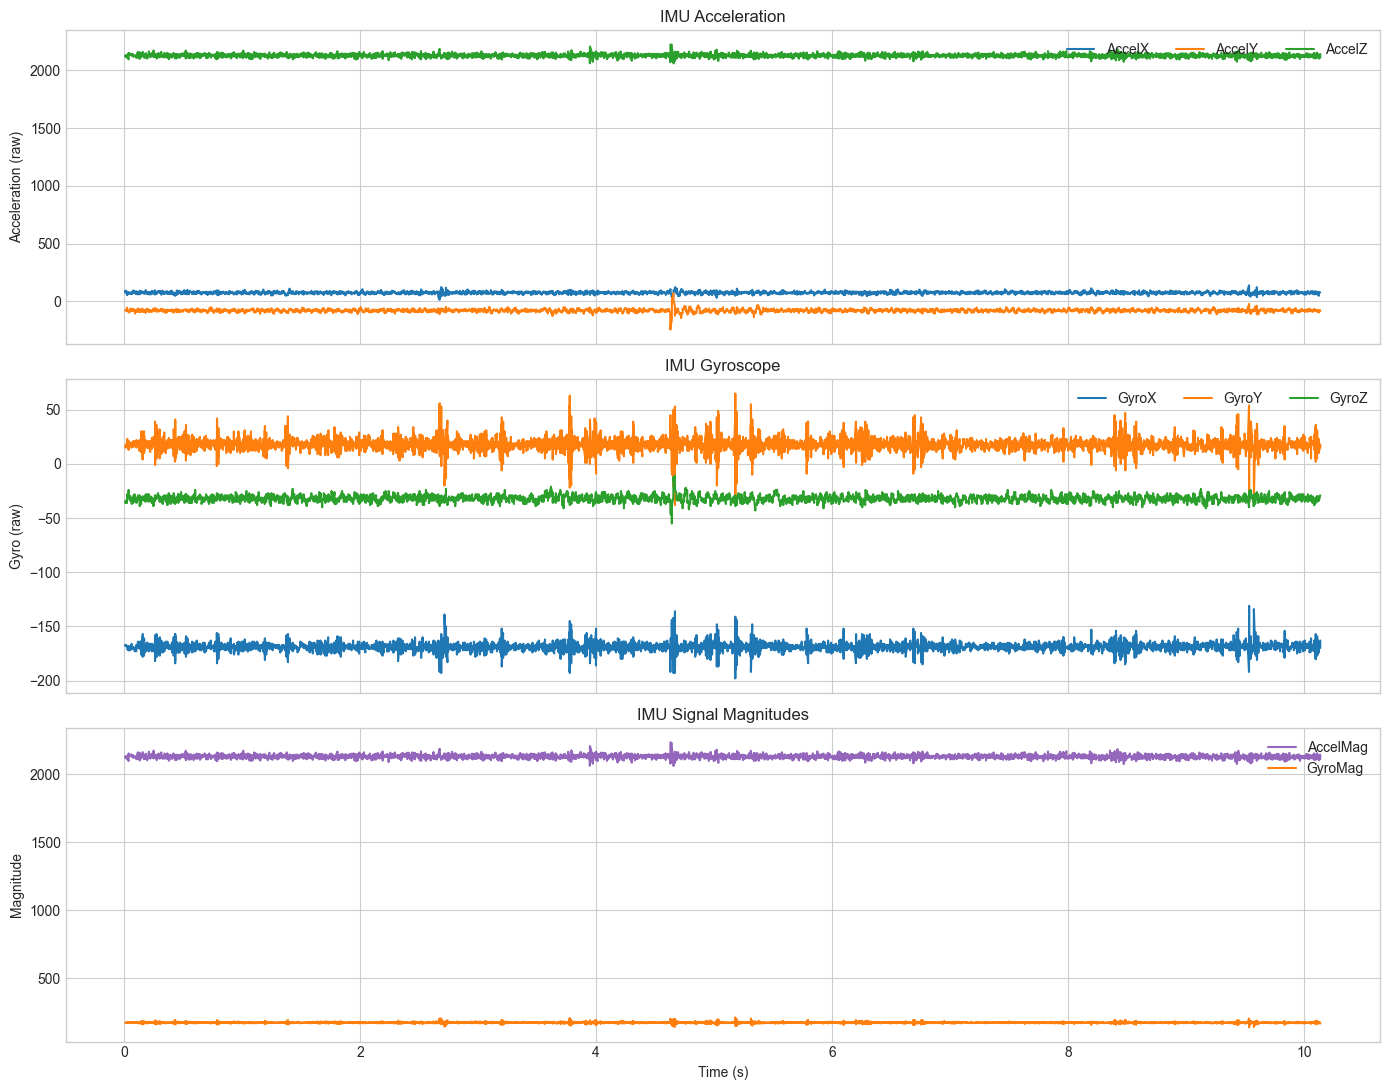

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(df["time_s"], df["AccelX"], label="AccelX")
axes[0].plot(df["time_s"], df["AccelY"], label="AccelY")
axes[0].plot(df["time_s"], df["AccelZ"], label="AccelZ")
axes[0].set_ylabel("Acceleration (raw)")
axes[0].set_title("IMU Acceleration")
axes[0].legend(loc="upper right", ncol=3)

axes[1].plot(df["time_s"], df["GyroX"], label="GyroX")
axes[1].plot(df["time_s"], df["GyroY"], label="GyroY")
axes[1].plot(df["time_s"], df["GyroZ"], label="GyroZ")
axes[1].set_ylabel("Gyro (raw)")
axes[1].set_title("IMU Gyroscope")
axes[1].legend(loc="upper right", ncol=3)

axes[2].plot(df["time_s"], df["AccelMag"], color="tab:purple", label="AccelMag")
axes[2].plot(df["time_s"], df["GyroMag"], color="tab:orange", label="GyroMag")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Magnitude")
axes[2].set_title("IMU Signal Magnitudes")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

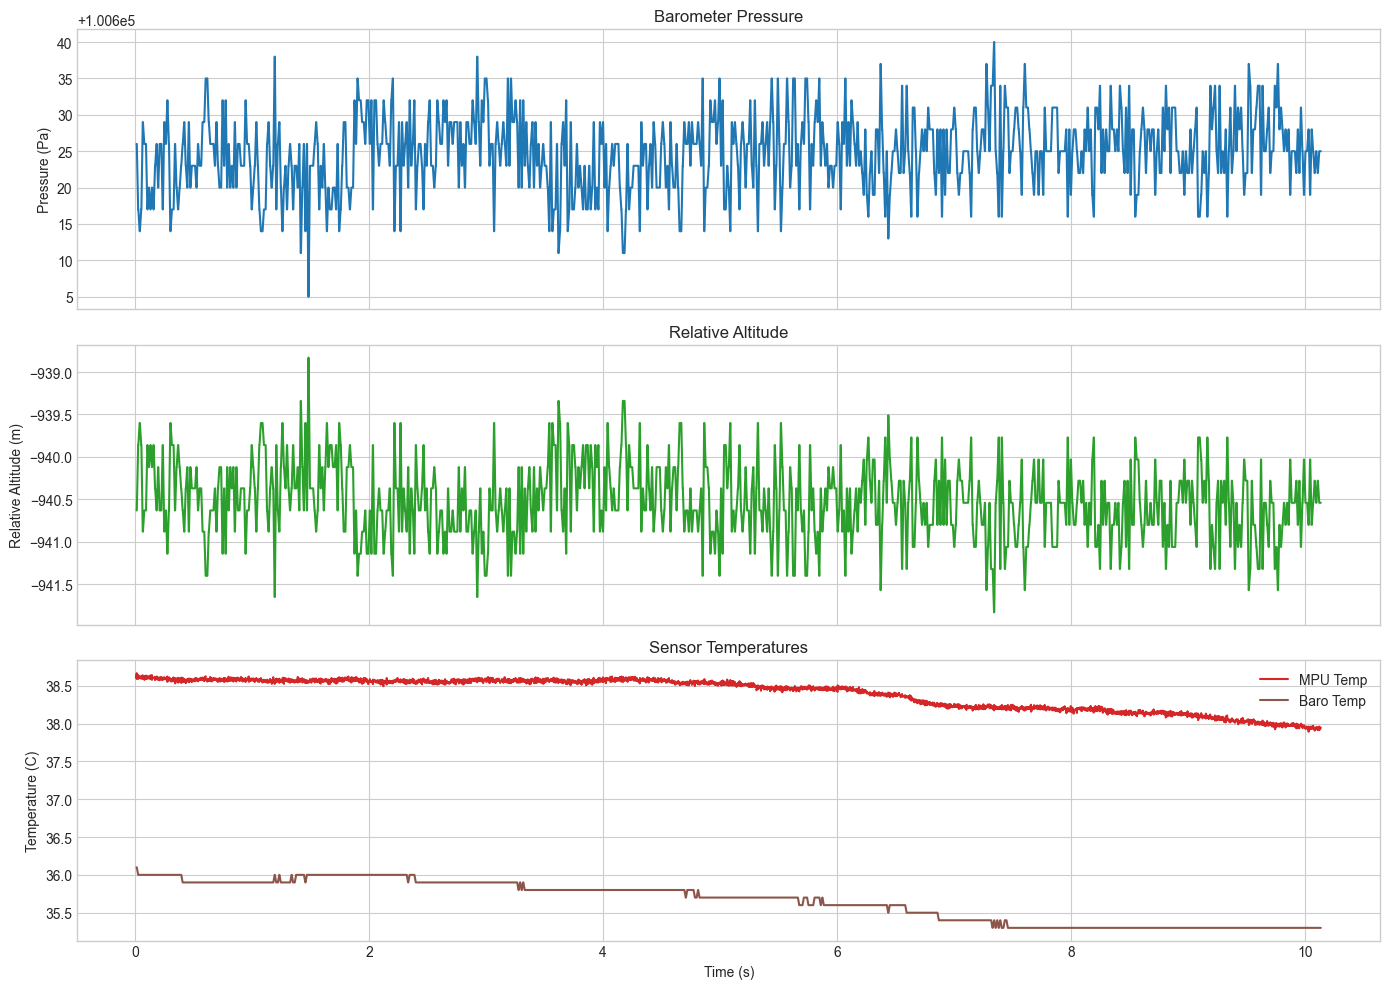

,records,duration_s,mean_dt_s,mean_rate_hz,pressure_mean_pa,rel_alt_mean_m,accel_mag_mean,gyro_mag_mean
0,3861,10.1367,0.0026,380.8935,100624.8146,-940.5265,2132.1241,172.8822


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df["time_s"], df["PressurePa"], color="tab:blue")
axes[0].set_ylabel("Pressure (Pa)")
axes[0].set_title("Barometer Pressure")

axes[1].plot(df["time_s"], df["RelAltM"], color="tab:green")
axes[1].set_ylabel("Relative Altitude (m)")
axes[1].set_title("Relative Altitude")

axes[2].plot(df["time_s"], df["MPUTempC"], label="MPU Temp", color="tab:red")
axes[2].plot(df["time_s"], df["BaroTempC"], label="Baro Temp", color="tab:brown")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Temperature (C)")
axes[2].set_title("Sensor Temperatures")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

record_count = len(df)
duration_s = float(df["time_s"].iloc[-1]) if record_count else 0.0
mean_dt = float(df["dt_s"].mean()) if record_count else np.nan
mean_rate_hz = (1.0 / mean_dt) if mean_dt > 0 else np.nan

summary = pd.DataFrame({
    "records": [record_count],
    "duration_s": [duration_s],
    "mean_dt_s": [mean_dt],
    "mean_rate_hz": [mean_rate_hz],
    "pressure_mean_pa": [df["PressurePa"].mean()],
    "rel_alt_mean_m": [df["RelAltM"].mean()],
    "accel_mag_mean": [df["AccelMag"].mean()],
    "gyro_mag_mean": [df["GyroMag"].mean()],
})

summary.round(4)

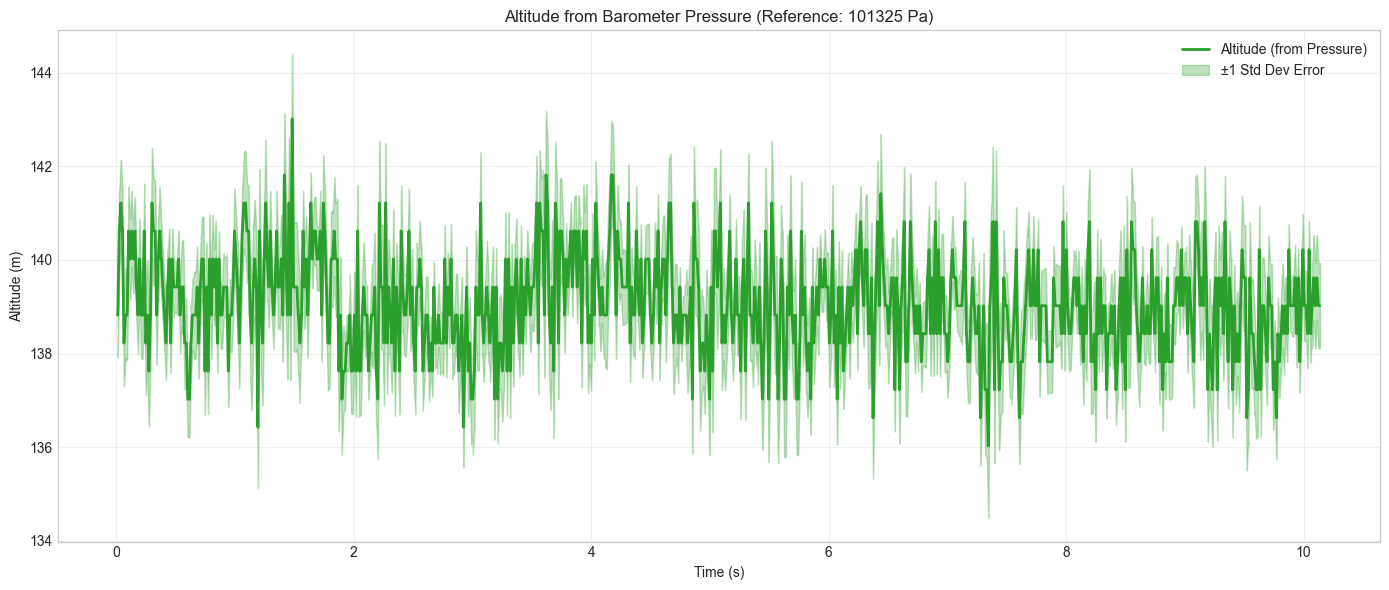

Altitude range: 136.03 to 143.01 m
Mean altitude: 139.06 m
Mean altitude error (std dev): 0.9118 m
Max altitude error: 1.6003 m


In [16]:
# Calculate altitude from pressure using barometric formula with reference pressure
P_sea_level = 101325  # Reference pressure in Pa
T0 = 288.15  # Standard temperature in K
L = 0.0065   # Temperature lapse rate K/m

P = df["PressurePa"].values
df["h_calculated"] = (T0 / L) * ((P_sea_level / P) ** (0.0288 / (9.81 * L)) - 1)

# Compute altitude error as rolling standard deviation (measurement noise estimate)
window_size = 50  # Window for rolling std dev
df["alt_error"] = df["h_calculated"].rolling(window=window_size, center=True).std()
df["alt_error"] = df["alt_error"].fillna(df["alt_error"].mean())  # Fill NaN at edges

fig, ax = plt.subplots(figsize=(14, 6))

# Plot altitude with error band
ax.plot(df["time_s"], df["h_calculated"], color="tab:green", linewidth=2, label="Altitude (from Pressure)")
ax.fill_between(
    df["time_s"],
    df["h_calculated"] - df["alt_error"],
    df["h_calculated"] + df["alt_error"],
    alpha=0.3,
    color="tab:green",
    label="±1 Std Dev Error"
)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Altitude (m)")
ax.set_title("Altitude from Barometer Pressure (Reference: 101325 Pa)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Altitude range: {df['h_calculated'].min():.2f} to {df['h_calculated'].max():.2f} m")
print(f"Mean altitude: {df['h_calculated'].mean():.2f} m")
print(f"Mean altitude error (std dev): {df['alt_error'].mean():.4f} m")
print(f"Max altitude error: {df['alt_error'].max():.4f} m")

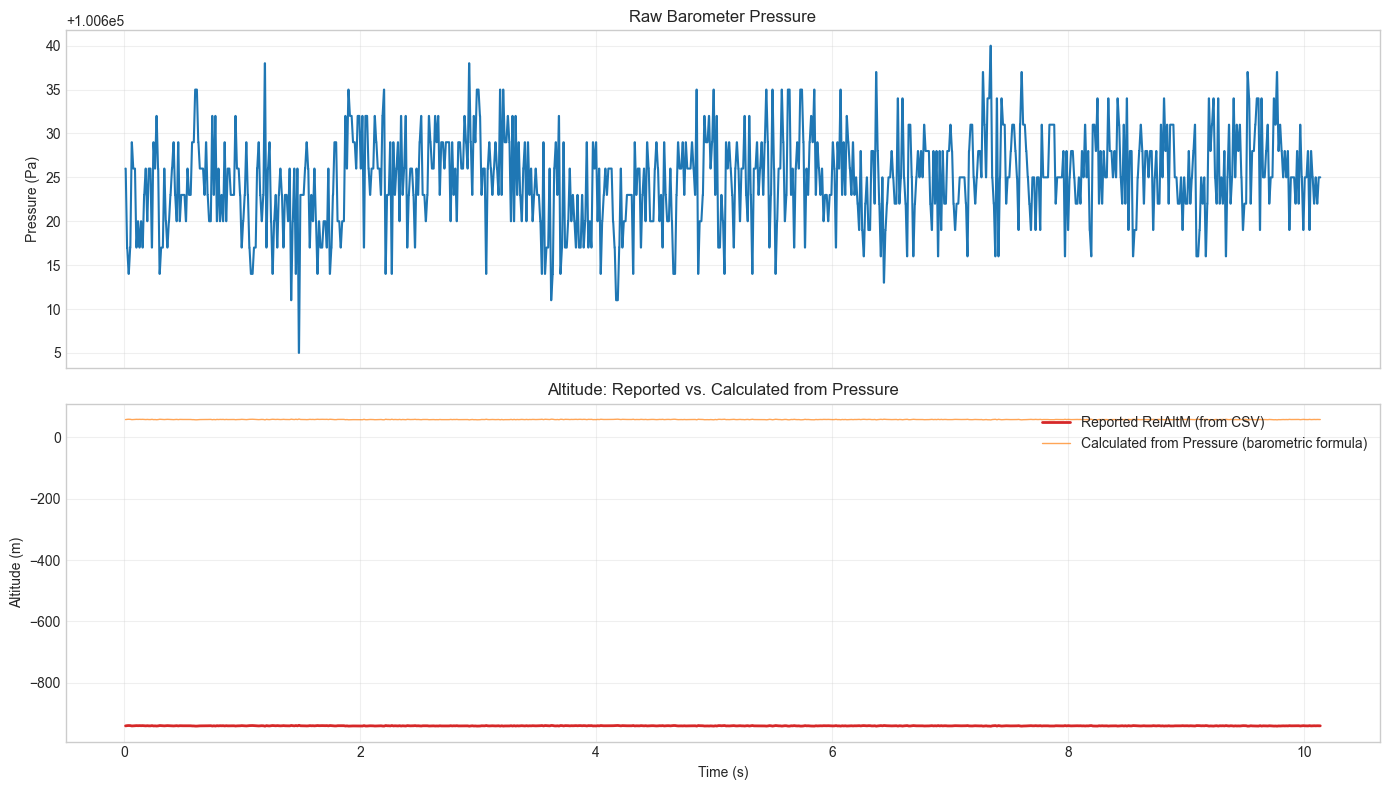

=== Pressure Analysis ===
Pressure range: 100605.0 to 100640.0 Pa
Mean pressure: 100624.8 Pa

=== Reported Altitude (RelAltM) ===
Range: -941.83 to -938.83 m
Mean: -940.53 m

=== Calculated Altitude (from pressure) ===
Range: 57.19 to 60.12 m
Mean: 58.46 m

⚠️ Difference suggests RelAltM may not be reset to ground level, or uses different reference.


In [17]:
# Investigate altitude calculation: raw pressure vs. reported altitude
# Using barometric formula: h = (T0 / L) * ((P0 / P)^(R*L/g) - 1)

P_sea_level = 101325  # Sea level pressure in Pa
T0 = 288.15  # Standard temperature in K
L = 0.0065   # Temperature lapse rate K/m

# Calculate altitude from pressure using barometric formula
P = df["PressurePa"].values
# h_calculated = (T0 / L) * ((P_sea_level / P) ** (0.0288 / (9.81 * L)) - 1)
h_calculated = 44330 * (1 - (P / P_sea_level) ** (1/5.255))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Pressure over time
axes[0].plot(df["time_s"], df["PressurePa"], color="tab:blue", linewidth=1.5)
axes[0].set_ylabel("Pressure (Pa)")
axes[0].set_title("Raw Barometer Pressure")
axes[0].grid(True, alpha=0.3)

# Plot 2: Altitude comparison
axes[1].plot(df["time_s"], df["RelAltM"], label="Reported RelAltM (from CSV)", color="tab:red", linewidth=2)
axes[1].plot(df["time_s"], h_calculated, label="Calculated from Pressure (barometric formula)", color="tab:orange", linewidth=1, alpha=0.7)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Altitude (m)")
axes[1].set_title("Altitude: Reported vs. Calculated from Pressure")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== Pressure Analysis ===")
print(f"Pressure range: {df['PressurePa'].min():.1f} to {df['PressurePa'].max():.1f} Pa")
print(f"Mean pressure: {df['PressurePa'].mean():.1f} Pa")
print(f"\n=== Reported Altitude (RelAltM) ===")
print(f"Range: {df['RelAltM'].min():.2f} to {df['RelAltM'].max():.2f} m")
print(f"Mean: {df['RelAltM'].mean():.2f} m")
print(f"\n=== Calculated Altitude (from pressure) ===")
print(f"Range: {h_calculated.min():.2f} to {h_calculated.max():.2f} m")
print(f"Mean: {h_calculated.mean():.2f} m")
print(f"\n⚠️ Difference suggests RelAltM may not be reset to ground level, or uses different reference.")